In [ ]:
!pip install segmentation-models-pytorch
!pip install -U git+https://github.com/albumentations-team/albumentations
!pip install --upgrade opencv-contrib-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.9 MB/s eta 0:00:00
  Cloning https://github.com/albumentations-team/albumentations to /tmp/pip-req-build-igvgxdon
  Running command git clone --filter=blob:none --quiet https://github.com/albumentations-team/albumentations /tmp/pip-req-build-igvgxdon
  Resolved https://github.com/albumentations-team/albumentations to commit 66212d77a44927a29d6a0e81621d3c27afbd929c
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


Downloading Dataset

The original author of the dataset is
https://github.com/VikramShenoy97/Human-Segmentation-Dataset


In [ ]:
!git clone https://github.com/parth1620/Human-Segmentation-Dataset-master.git

Cloning into 'Human-Segmentation-Dataset-master'...
remote: Enumerating objects: 592, done.
remote: Counting objects: 100% (592/592), done.
remote: Compressing objects: 100% (591/591), done.
remote: Total 592 (delta 3), reused 588 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (592/592), 13.60 MiB | 18.87 MiB/s, done.
Resolving deltas: 100% (3/3), done.


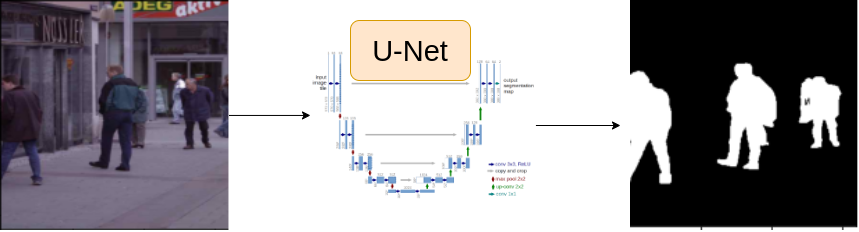

# Some Common Imports

In [ ]:
import sys
sys.path.append('/content/Human-Segmentation-Dataset-master')

In [ ]:
import torch
import cv2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tqdm import tqdm

import helper

#  Setup Configurations

In [ ]:
CSV_file = '/content/Human-Segmentation-Dataset-master/train.csv'
Data_Path = '/content/'

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
EPOCHs = 25
LR = 0.003
IMG_SIZE = 320
BATCH_SIZE = 16
ENCODER = 'timm-efficientnet-b0'
WEIGHTS = 'imagenet'

In [ ]:
df = pd.read_csv (CSV_file)
df.head()

,masks,images
0,Human-Segmentation-Dataset-master/Ground_Truth...,Human-Segmentation-Dataset-master/Training_Ima...
1,Human-Segmentation-Dataset-master/Ground_Truth...,Human-Segmentation-Dataset-master/Training_Ima...
2,Human-Segmentation-Dataset-master/Ground_Truth...,Human-Segmentation-Dataset-master/Training_Ima...
3,Human-Segmentation-Dataset-master/Ground_Truth...,Human-Segmentation-Dataset-master/Training_Ima...
4,Human-Segmentation-Dataset-master/Ground_Truth...,Human-Segmentation-Dataset-master/Training_Ima...


In [ ]:
row = df.iloc[1]
image_path = row.images
mask_path = row.masks

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE) / 255.0



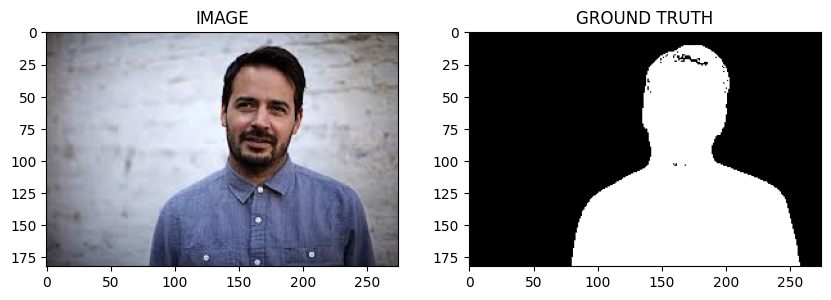

In [ ]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

ax1.set_title('IMAGE')
ax1.imshow(image)

ax2.set_title('GROUND TRUTH')
ax2.imshow(mask,cmap = 'gray')

In [ ]:
train_df, valid_df = train_test_split(df, test_size=0.2, random_state=42)

# Augmentation Functions

albumentation documentation : https://albumentations.ai/docs/

In [ ]:
import albumentations as A

In [ ]:
def get_train_augs():
  return A.Compose([
      A.Resize(IMG_SIZE, IMG_SIZE),
      A.HorizontalFlip(p=0.5),
      A.VerticalFlip(p=0.5)
  ], is_check_shapes=False)

def get_valid_augs():
  return A.Compose([
      A.Resize(IMG_SIZE, IMG_SIZE)
  ], is_check_shapes=False)

# Create Custom Dataset

In [ ]:
from torch.utils.data import Dataset

In [ ]:
class SegmentationDataset(Dataset):
  def __init__(self, df, augmentations):
    self.df = df
    self.augmentations = augmentations

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    row = self.df.iloc[idx]

    image_path = row.images
    mask_path = row.masks

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = np.expand_dims(mask, axis = -1)

    if self.augmentations:
      data = self.augmentations(image = image, mask = mask)
      image = data['image']
      mask = data['mask']

    image = np.transpose(image, (2,0,1)).astype(np.float32)
    mask = np.transpose(mask, (2,0,1)).astype(np.float32)

    image = torch.Tensor(image) / 255.0
    mask = torch.round(torch.Tensor(mask) / 255.0)

    return image, mask



In [ ]:
trainset = SegmentationDataset(train_df, get_train_augs())
validset = SegmentationDataset(valid_df, get_valid_augs())


In [ ]:
print(f"Size of Trainset : {len(trainset)}")
print(f"Size of Validset : {len(validset)}")

Size of Trainset : 232
Size of Validset : 58


In [ ]:
def show_image(image, mask, pred_mask=None):
  f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

  ax1.set_title('IMAGE')
  ax1.imshow(image.cpu().permute(1, 2, 0) if isinstance(image, torch.Tensor) else image)

  ax2.set_title('GROUND TRUTH')
  ax2.imshow(mask.cpu().permute(1, 2, 0) if isinstance(mask, torch.Tensor) else mask, cmap='gray')

  if pred_mask is not None:
    ax3.set_title('PREDICTED MASK')
    ax3.imshow(pred_mask.cpu().permute(1, 2, 0) if isinstance(pred_mask, torch.Tensor) else pred_mask, cmap='gray')

  plt.show()

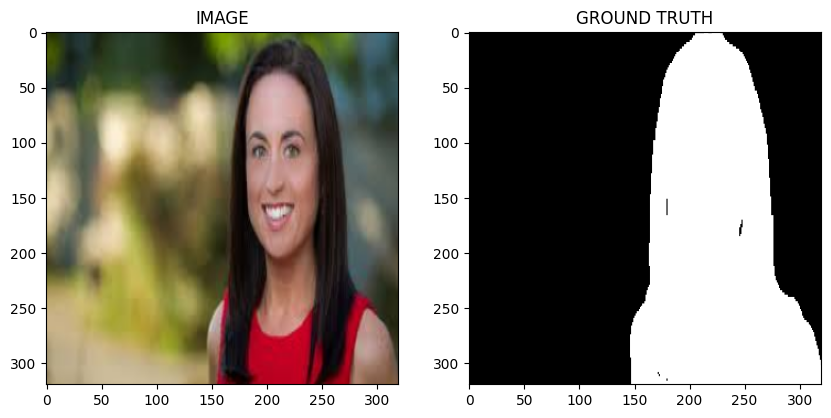

In [ ]:
idx = 22 # Using the same index you had
image, mask = trainset[idx]
show_image(image, mask)

# Load dataset into batches

In [ ]:
from torch.utils.data import DataLoader

In [ ]:
trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
validloader = DataLoader(validset, batch_size=BATCH_SIZE)

In [ ]:
print(f'total number of batches in trainloader : {len(trainloader)}')
print(f'total number of batches in validloader : {len(validloader)}')

total number of batches in trainloader : 15
total number of batches in validloader : 4


In [ ]:
for image, mask in trainloader:
  print(f'image shape : {image.shape}')
  print(f'mask shape : {mask.shape}')
  break # Keeping break for the first batch only

image shape : torch.Size([16, 3, 320, 320])
mask shape : torch.Size([16, 1, 320, 320])


#  Create Segmentation Model

segmentation_models_pytorch documentation : https://smp.readthedocs.io/en/latest/

In [ ]:
from torch import nn
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.losses import DiceLoss

In [ ]:
class SegmentationModel(nn.Module):
  def __init__(self):
    super(SegmentationModel, self).__init__()

    self.arc = smp.Unet(
        encoder_name = ENCODER,
        encoder_weights = WEIGHTS,
        in_channels = 3,
        classes =1,
        activation= None
    )
  def forward(self, images, masks = None):
    logits = self.arc(images)

    if masks is not None:
      loss1 = DiceLoss(mode='binary')(logits, masks)
      loss2 = nn.BCEWithLogitsLoss()(logits, masks)
      return logits, loss1 + loss2
    return logits


In [ ]:
model = SegmentationModel()
model.to(DEVICE);

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

#  Create Train and Validation Function

In [ ]:
def train_fn(data_loader,model,optimizer):
  model.train()
  total_loss = 0.0

  for images, masks in tqdm(data_loader):
    images = images.to(DEVICE)
    masks = masks.to(DEVICE)

    optimizer.zero_grad()
    logits, loss = model(images, masks)
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  return total_loss / len(data_loader)

In [ ]:
def eval_fn(data_loader,model):
  model.eval()
  total_loss = 0.0

  with torch.no_grad():
    for images, masks in tqdm(data_loader):
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        logits, loss = model(images, masks)
        total_loss += loss.item()

  return total_loss / len(data_loader)

# Train Model

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)


In [ ]:
best_valid_loss = float('inf')

for i in range(EPOCHs):
  train_loss = train_fn(trainloader, model, optimizer)
  valid_loss = eval_fn(validloader, model)

  if valid_loss < best_valid_loss:
    torch.save(model.state_dict(), 'best_model.pt')
    print('Saved Best Model!')
    best_valid_loss = valid_loss

  print(f'Epoch : {i+1}Train_loss:{train_loss} Valid_loss:{valid_loss}')

100%|██████████| 4/4 [00:00<00:00,  5.75it/s]


Saved Best Model!
Epoch : 1Train_loss:0.7797118385632833 Valid_loss:3.3671668767929077


100%|██████████| 4/4 [00:00<00:00,  5.73it/s]


Saved Best Model!
Epoch : 2Train_loss:0.34963069756825765 Valid_loss:0.694372370839119


100%|██████████| 4/4 [00:00<00:00,  6.17it/s]


...

Epoch : 23Train_loss:0.17386524826288224 Valid_loss:0.2547158971428871


100%|██████████| 4/4 [00:00<00:00,  5.46it/s]


Epoch : 24Train_loss:0.14900260120630265 Valid_loss:0.2562236040830612


100%|██████████| 4/4 [00:00<00:00,  6.27it/s]

Epoch : 25Train_loss:0.12744143505891165 Valid_loss:0.22778136283159256


# Inference

In [ ]:
idx = 20

model.load_state_dict(torch.load('/content/best_model.pt'))
image, mask = validset[idx]
logits_mask = model(image.to(DEVICE).unsqueeze(0))
logits_mask = logits_mask.cpu().squeeze(0)
pred_mask = torch.sigmoid(logits_mask)
pred_mask = (pred_mask > 0.5)*1.0



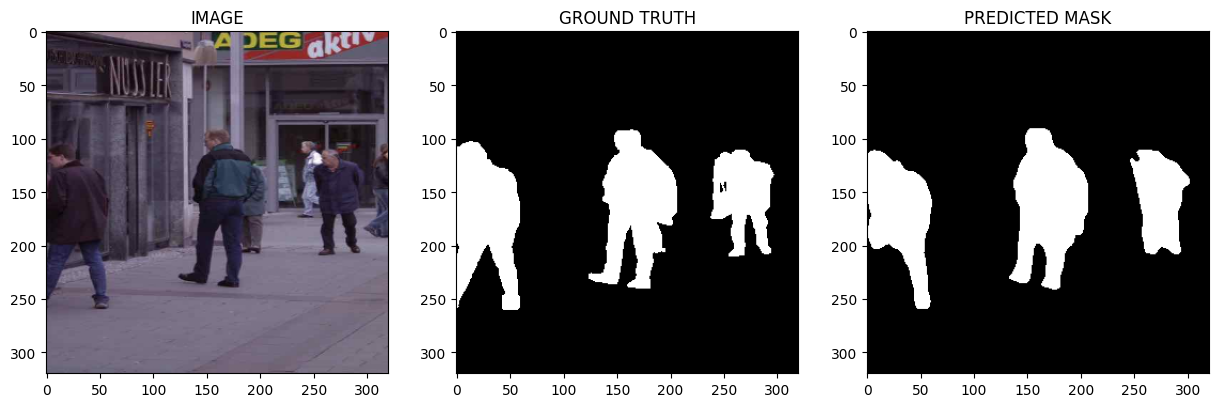

In [ ]:
show_image(image, mask, pred_mask.detach().cpu())

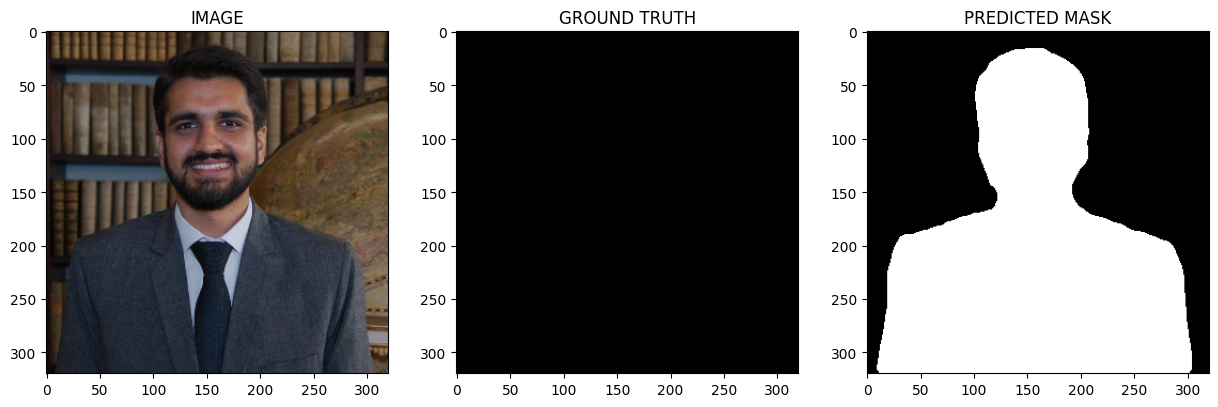

In [ ]:
# Load and Preprocess Your Personal Image ---

personal_image_path = '/content/Myphoto1.jpeg' # Example path, change this!

# Load image using OpenCV
personal_image = cv2.imread(personal_image_path)

# Check if image loaded successfully
if personal_image is None:
    print(f"Error: Could not load image from {personal_image_path}")
else:
    # Convert BGR to RGB
    personal_image = cv2.cvtColor(personal_image, cv2.COLOR_BGR2RGB)

    # Apply validation augmentations (resizing)
    # Note: We create a temporary augmentation composer for a single image
    # We don't want to use get_valid_augs() directly as it's designed for datasets
    test_augs = A.Compose([A.Resize(IMG_SIZE, IMG_SIZE)], is_check_shapes=False)
    augmented_data = test_augs(image=personal_image)
    processed_image = augmented_data['image']

    # Store the original-sized processed image for visualization later
    display_image = processed_image.copy()

    # Transpose dimensions (H, W, C) to (C, H, W) and convert to float32
    processed_image = np.transpose(processed_image, (2, 0, 1)).astype(np.float32)

    # Convert to PyTorch Tensor and normalize
    processed_image_tensor = torch.Tensor(processed_image) / 255.0

    # Add a batch dimension (1, C, H, W) for model input
    processed_image_tensor = processed_image_tensor.unsqueeze(0).to(DEVICE)

    # --- Step 2: Perform Inference ---
    model.eval() # Set model to evaluation mode
    with torch.no_grad():
        logits = model(processed_image_tensor)

    # --- Step 3: Postprocess Prediction ---
    logits = logits.cpu().squeeze(0) # Move to CPU and remove batch dimension
    pred_mask = torch.sigmoid(logits) # Apply sigmoid to get probabilities
    pred_mask = (pred_mask > 0.5).float() # Threshold to get binary mask

    # --- Step 4: Visualize Results ---
    # For show_image, we need the original image before the unsqueeze for better display
    # and the predicted mask (which is already squeezed and on CPU)
    show_image(torch.Tensor(display_image).permute(2,0,1)/255.0, # Convert back to Tensor for show_image compat
               torch.zeros_like(pred_mask), # Placeholder for mask as we don't have GT for personal image
               pred_mask)

# For updates about upcoming and current guided projects follow me on...

Twitter : @parth_AI

Linkedin : www.linkedin.com/in/pdhameliya